# Full LightGBM Tuning

This notebook tunes LightGBM specifically, comparing five configurations that vary the number of leaves, depth, and regularization strength, using the same nested five-fold approach as the earlier tuning notebooks.


## Import libraries


In [3]:
from pathlib import Path
import gc
import json
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    average_precision_score, roc_auc_score,
    RocCurveDisplay, PrecisionRecallDisplay
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder

try:
    import lightgbm as lgb
except ImportError as error:
    raise ImportError("Install LightGBM first: pip install lightgbm") from error

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 150)
print("LightGBM version:", lgb.__version__)
print("Libraries imported successfully.")


LightGBM version: 4.6.0
Libraries imported successfully.


## Set paths and experiment settings


In [5]:
current_folder = Path.cwd().resolve()
project_root = current_folder.parent if current_folder.name == "notebooks" else current_folder
dataset_path = project_root / "data" / "modeling" / "final_feature_dataset.pkl"
training_ids_path = project_root / "data" / "modeling" / "splits" / "training_ids.csv"
test_ids_path = project_root / "data" / "modeling" / "splits" / "test_ids.csv"
folds_path = project_root / "data" / "modeling" / "splits" / "training_fold_assignments.csv"
xgboost_oof_path = project_root / "data" / "modeling" / "xgboost_tuning_results" / "xgboost_tuning_oof_predictions.pkl"
catboost_oof_path = project_root / "data" / "modeling" / "catboost_tuning_results" / "native_catboost_oof_predictions.pkl"
previous_boosted_path = project_root / "data" / "modeling" / "boosted_results" / "boosted_oof_predictions.pkl"
result_folder = project_root / "data" / "modeling" / "lightgbm_tuning_results"
figure_folder = project_root / "reports" / "figures"
audit_folder = project_root / "reports" / "audits"

for folder in [result_folder, figure_folder, audit_folder]:
    folder.mkdir(parents=True, exist_ok=True)
for path in [dataset_path, training_ids_path, test_ids_path, folds_path]:
    assert path.exists(), f"Required file missing: {path}"

RANDOM_STATE = 2026
EXPECTED_TRAINING_ROWS = 246008
MAX_BOOSTING_ROUNDS = 6000
EARLY_STOPPING_ROUNDS = 250
print("Maximum boosting rounds:", MAX_BOOSTING_ROUNDS)
print("Early-stopping patience:", EARLY_STOPPING_ROUNDS)


Maximum boosting rounds: 6000
Early-stopping patience: 250


## Load the complete training dataset


In [7]:
full_data = pd.read_pickle(dataset_path)
training_ids = pd.read_csv(training_ids_path)["SK_ID_CURR"]
test_ids = pd.read_csv(test_ids_path)["SK_ID_CURR"]
fold_assignments = pd.read_csv(folds_path)

training_id_set = set(training_ids)
test_id_set = set(test_ids)
training_data = full_data.loc[full_data["SK_ID_CURR"].isin(training_id_set)].copy()
training_data = training_data.merge(
    fold_assignments, on="SK_ID_CURR", how="left", validate="one_to_one"
)

assert len(training_data) == EXPECTED_TRAINING_ROWS
assert training_data["FOLD"].nunique() == 5
assert not training_data["SK_ID_CURR"].isin(test_id_set).any()
print("Training rows:", len(training_data))
print("Final test rows excluded:", len(test_ids))
print("Default rate:", round(training_data["TARGET"].mean(), 5))


Training rows: 246008
Final test rows excluded: 61503
Default rate: 0.08073


Same training data and folds as before.


## Prepare predictors without leakage


In [10]:
excluded_columns = ["SK_ID_CURR", "TARGET", "FOLD", "CODE_GENDER"]
predictor_columns = [c for c in training_data.columns if c not in excluded_columns]
categorical_columns = training_data[predictor_columns].select_dtypes(exclude="number").columns.tolist()
numerical_columns = [c for c in predictor_columns if c not in categorical_columns]

X = training_data[predictor_columns].copy()
y = training_data["TARGET"].astype("int8").copy()
folds = training_data["FOLD"].astype(int).copy()
for column in categorical_columns:
    X[column] = X[column].fillna("Unknown").astype(str)

def make_preprocessor():
    return ColumnTransformer([
        ("numeric", "passthrough", numerical_columns),
        ("categorical", OrdinalEncoder(
            handle_unknown="use_encoded_value", unknown_value=-1,
            dtype=np.float32
        ), categorical_columns),
    ], sparse_threshold=0.0)

print("Predictors used:", len(predictor_columns))
print("Numerical predictors:", len(numerical_columns))
print("Categorical predictors:", len(categorical_columns))
print("Numerical missing cells handled natively:", int(X[numerical_columns].isna().sum().sum()))


Predictors used: 330
Numerical predictors: 318
Categorical predictors: 12
Numerical missing cells handled natively: 1918164


Same 330 predictors and ordinal-encoded categoricals as the boosted-tree comparison notebook.


## Define meaningful LightGBM configurations


In [13]:
candidate_configurations = {
    "lgb_leaves24_conservative": {
        "learning_rate": 0.025, "num_leaves": 24, "max_depth": -1,
        "min_child_samples": 60, "min_split_gain": 0.0,
        "subsample": 1.00, "subsample_freq": 0, "colsample_bytree": 0.90,
        "reg_alpha": 0.10, "reg_lambda": 8.0,
    },
    "lgb_leaves31_reference": {
        "learning_rate": 0.03, "num_leaves": 31, "max_depth": -1,
        "min_child_samples": 40, "min_split_gain": 0.0,
        "subsample": 1.00, "subsample_freq": 0, "colsample_bytree": 0.90,
        "reg_alpha": 0.10, "reg_lambda": 5.0,
    },
    "lgb_leaves31_sampled": {
        "learning_rate": 0.025, "num_leaves": 31, "max_depth": -1,
        "min_child_samples": 50, "min_split_gain": 0.01,
        "subsample": 0.85, "subsample_freq": 1, "colsample_bytree": 0.85,
        "reg_alpha": 0.25, "reg_lambda": 8.0,
    },
    "lgb_leaves48_regularized": {
        "learning_rate": 0.02, "num_leaves": 48, "max_depth": -1,
        "min_child_samples": 80, "min_split_gain": 0.02,
        "subsample": 0.90, "subsample_freq": 1, "colsample_bytree": 0.85,
        "reg_alpha": 0.50, "reg_lambda": 12.0,
    },
    "lgb_leaves63_depth8": {
        "learning_rate": 0.02, "num_leaves": 63, "max_depth": 8,
        "min_child_samples": 60, "min_split_gain": 0.01,
        "subsample": 0.90, "subsample_freq": 1, "colsample_bytree": 0.90,
        "reg_alpha": 0.25, "reg_lambda": 10.0,
    },
}
configuration_table = pd.DataFrame(candidate_configurations).T.reset_index().rename(
    columns={"index": "configuration"}
)
configuration_table


,configuration,learning_rate,num_leaves,max_depth,min_child_samples,min_split_gain,subsample,subsample_freq,colsample_bytree,reg_alpha,reg_lambda
0,lgb_leaves24_conservative,0.025,24.0,-1.0,60.0,0.00,1.00,0.0,0.90,0.10,8.0
1,lgb_leaves31_reference,0.030,31.0,-1.0,40.0,0.00,1.00,0.0,0.90,0.10,5.0
2,lgb_leaves31_sampled,0.025,31.0,-1.0,50.0,0.01,0.85,1.0,0.85,0.25,8.0
3,lgb_leaves48_regularized,0.020,48.0,-1.0,80.0,0.02,0.90,1.0,0.85,0.50,12.0
4,lgb_leaves63_depth8,0.020,63.0,8.0,60.0,0.01,0.90,1.0,0.90,0.25,10.0


Five configurations to compare, mostly varying the number of leaves per tree and regularization strength, from a conservative 24-leaf setup up to a deeper 63-leaf one.


## Model and metric functions


In [16]:
def build_lightgbm(configuration, n_estimators):
    return lgb.LGBMClassifier(
        n_estimators=n_estimators,
        **configuration,
        objective="binary", max_bin=255,
        n_jobs=-1, random_state=RANDOM_STATE, verbosity=-1,
    )

def calculate_metrics(y_true, probability):
    return {
        "roc_auc": roc_auc_score(y_true, probability),
        "pr_auc": average_precision_score(y_true, probability),
    }

print("Functions created.")


Functions created.


Builds a LightGBM model from one of the five candidate settings, and reuses the same ROC-AUC/PR-AUC scoring as before.


## Run full nested five-fold tuning


In [19]:
oof_predictions = pd.DataFrame({
    "SK_ID_CURR": training_data["SK_ID_CURR"].to_numpy(),
    "TARGET": y.to_numpy(),
    "FOLD": folds.to_numpy(),
})
fold_rows = []
iteration_rows = []

for configuration_name, configuration in candidate_configurations.items():
    print(f"\nCONFIGURATION: {configuration_name}")
    configuration_oof = np.full(len(X), np.nan, dtype="float64")

    for fold_number in sorted(folds.unique()):
        outer_train_indices = np.flatnonzero(folds.ne(fold_number).to_numpy())
        outer_valid_indices = np.flatnonzero(folds.eq(fold_number).to_numpy())
        inner_train_indices, inner_valid_indices = train_test_split(
            outer_train_indices, test_size=0.10,
            stratify=y.iloc[outer_train_indices],
            random_state=RANDOM_STATE + int(fold_number)
        )

        inner_preprocessor = make_preprocessor()
        X_inner_train = inner_preprocessor.fit_transform(X.iloc[inner_train_indices]).astype("float32")
        X_inner_valid = inner_preprocessor.transform(X.iloc[inner_valid_indices]).astype("float32")

        search_model = build_lightgbm(configuration, MAX_BOOSTING_ROUNDS)
        search_model.fit(
            X_inner_train, y.iloc[inner_train_indices],
            eval_set=[(X_inner_valid, y.iloc[inner_valid_indices])],
            eval_metric="auc",
            callbacks=[
                lgb.early_stopping(EARLY_STOPPING_ROUNDS, verbose=False),
                lgb.log_evaluation(0),
            ],
        )
        selected_rounds = int(search_model.best_iteration_)
        assert 1 <= selected_rounds <= MAX_BOOSTING_ROUNDS

        del inner_preprocessor, X_inner_train, X_inner_valid, search_model
        gc.collect()

        outer_preprocessor = make_preprocessor()
        X_outer_train = outer_preprocessor.fit_transform(X.iloc[outer_train_indices]).astype("float32")
        X_outer_valid = outer_preprocessor.transform(X.iloc[outer_valid_indices]).astype("float32")

        final_model = build_lightgbm(configuration, selected_rounds)
        start_time = time.time()
        final_model.fit(X_outer_train, y.iloc[outer_train_indices])
        probability = final_model.predict_proba(X_outer_valid)[:, 1]
        elapsed_minutes = (time.time() - start_time) / 60

        configuration_oof[outer_valid_indices] = probability
        metrics = calculate_metrics(y.iloc[outer_valid_indices], probability)
        metrics.update({
            "configuration": configuration_name, "fold": int(fold_number),
            "selected_rounds": selected_rounds,
            "outer_train_rows": len(outer_train_indices),
            "outer_validation_rows": len(outer_valid_indices),
            "refit_minutes": elapsed_minutes,
        })
        fold_rows.append(metrics)
        iteration_rows.append({
            "configuration": configuration_name, "fold": int(fold_number),
            "selected_rounds": selected_rounds
        })
        print(
            f"  Fold {fold_number}: rounds={selected_rounds}, "
            f"AUC={metrics['roc_auc']:.5f}, PR AUC={metrics['pr_auc']:.5f}, "
            f"minutes={elapsed_minutes:.2f}"
        )

        del outer_preprocessor, X_outer_train, X_outer_valid, final_model, probability
        gc.collect()

    assert not np.isnan(configuration_oof).any()
    oof_predictions[configuration_name] = configuration_oof

fold_metrics = pd.DataFrame(fold_rows)
selected_rounds_table = pd.DataFrame(iteration_rows)
print("\nAll LightGBM tuning fits completed.")



CONFIGURATION: lgb_leaves24_conservative


/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  Fold 1: rounds=1556, AUC=0.79005, PR AUC=0.28321, minutes=0.49


/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  Fold 2: rounds=1855, AUC=0.78975, PR AUC=0.28301, minutes=0.56


...

  Fold 3: rounds=1390, AUC=0.78414, PR AUC=0.27833, minutes=0.87


/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  Fold 4: rounds=994, AUC=0.79027, PR AUC=0.27755, minutes=0.67


/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  Fold 5: rounds=755, AUC=0.79148, PR AUC=0.28459, minutes=0.52

All LightGBM tuning fits completed.


Same nested approach as before, an inner split decides the number of rounds for each outer fold, then the model refits on the full outer-training data with that count.


## Compare complete OOF performance


In [22]:
overall_rows = []
for configuration_name in candidate_configurations:
    metrics = calculate_metrics(oof_predictions["TARGET"], oof_predictions[configuration_name])
    config_folds = fold_metrics.loc[fold_metrics["configuration"].eq(configuration_name)]
    metrics.update({
        "configuration": configuration_name,
        "fold_auc_mean": config_folds["roc_auc"].mean(),
        "fold_auc_std": config_folds["roc_auc"].std(),
        "fold_pr_auc_mean": config_folds["pr_auc"].mean(),
        "mean_selected_rounds": config_folds["selected_rounds"].mean(),
        "total_refit_minutes": config_folds["refit_minutes"].sum(),
    })
    overall_rows.append(metrics)

overall_metrics = pd.DataFrame(overall_rows).sort_values(
    ["roc_auc", "pr_auc"], ascending=False
).reset_index(drop=True)
best_configuration_name = overall_metrics.iloc[0]["configuration"]
best_configuration = candidate_configurations[best_configuration_name]
overall_metrics.round(6)


,roc_auc,pr_auc,configuration,fold_auc_mean,fold_auc_std,fold_pr_auc_mean,mean_selected_rounds,total_refit_minutes
0,0.789661,0.282529,lgb_leaves48_regularized,0.789764,0.002450,0.283200,1206.2,3.691304
1,0.789632,0.281882,lgb_leaves63_depth8,0.789724,0.003223,0.282241,1078.0,3.487663
2,0.789451,0.282199,lgb_leaves31_sampled,0.789486,0.002981,0.282705,1132.8,2.771908
3,0.788189,0.280396,lgb_leaves24_conservative,0.788207,0.003143,0.280910,1582.6,2.479147
4,0.787545,0.279706,lgb_leaves31_reference,0.787603,0.003345,0.280217,891.8,1.954674


The 48-leaf, more regularized configuration comes out on top, though all five are close together. This is the one that gets carried forward.


## Compare with tuned XGBoost, tuned CatBoost and previous LightGBM


In [25]:
comparison_rows = overall_metrics[
    ["configuration", "roc_auc", "pr_auc"]
].copy()

def add_saved_models(path, prefix, selected_columns=None):
    global comparison_rows
    if not path.exists():
        return
    saved_oof = pd.read_pickle(path)
    available = [c for c in saved_oof.columns if c not in ["SK_ID_CURR", "TARGET", "FOLD"]]
    if selected_columns is not None:
        available = [c for c in available if c in selected_columns]
    for column in available:
        row = calculate_metrics(saved_oof["TARGET"], saved_oof[column])
        row["configuration"] = prefix + column
        comparison_rows = pd.concat([comparison_rows, pd.DataFrame([row])], ignore_index=True)

add_saved_models(xgboost_oof_path, "xgboost_")
add_saved_models(catboost_oof_path, "catboost_")
add_saved_models(previous_boosted_path, "previous_", selected_columns=["lightgbm"])

comparison_rows = comparison_rows.sort_values("roc_auc", ascending=False).reset_index(drop=True)
comparison_rows.round(6)


,configuration,roc_auc,pr_auc
0,lgb_leaves48_regularized,0.789661,0.282529
1,lgb_leaves63_depth8,0.789632,0.281882
2,xgboost_xgb_depth5_regularized,0.789620,0.282323
3,lgb_leaves31_sampled,0.789451,0.282199
4,xgboost_xgb_depth6_sampled,0.789410,0.282360
5,xgboost_xgb_depth7_regularized,0.789118,0.280912
6,catboost_native_depth7_regularized,0.788938,0.282501
7,catboost_native_depth6,0.788668,0.282128
8,xgboost_xgb_leafwise_64,0.788642,0.281401
9,lgb_leaves24_conservative,0.788189,0.280396


This configuration ends up being the strongest individual model out of all three boosting families tested across notebooks 24-26.


## Plot tuned OOF curves


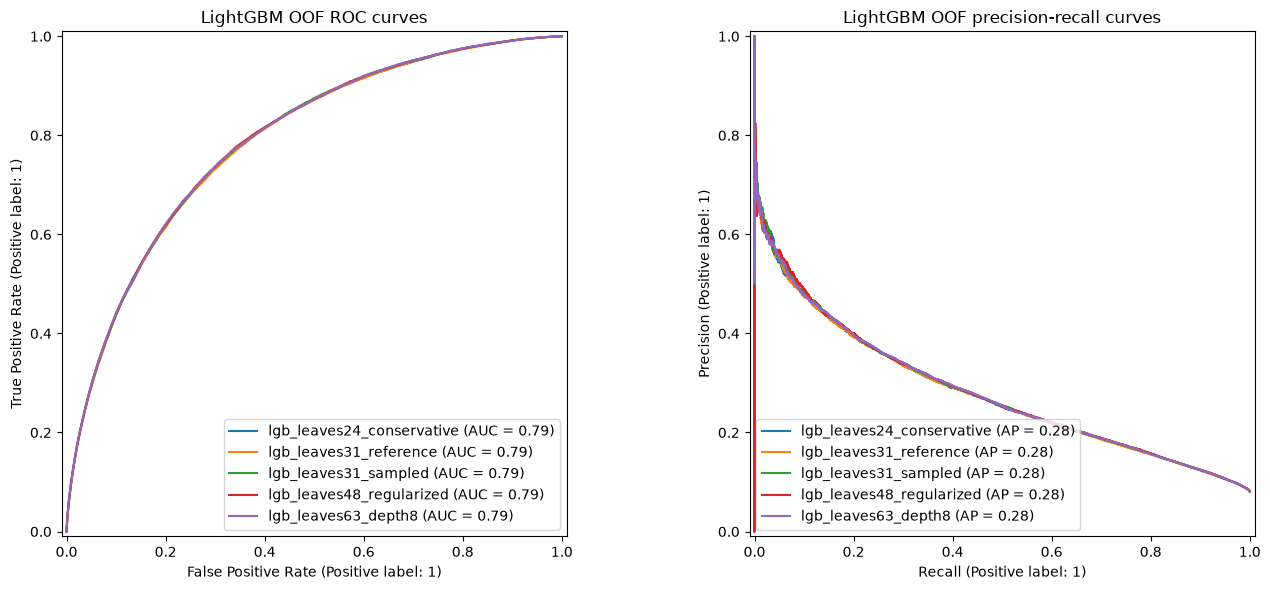

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for configuration_name in candidate_configurations:
    RocCurveDisplay.from_predictions(
        oof_predictions["TARGET"], oof_predictions[configuration_name],
        name=configuration_name, ax=axes[0]
    )
    PrecisionRecallDisplay.from_predictions(
        oof_predictions["TARGET"], oof_predictions[configuration_name],
        name=configuration_name, ax=axes[1]
    )
axes[0].set_title("LightGBM OOF ROC curves")
axes[1].set_title("LightGBM OOF precision-recall curves")
plt.tight_layout()
plt.savefig(figure_folder / "lightgbm_tuning_oof_curves.png", dpi=160, bbox_inches="tight")
plt.show()


Same idea as before, one curve per configuration tested.


## Validate and save outputs


In [31]:
validation_checks = pd.DataFrame([
    {"check": "Complete training dataset used", "passed": len(X) == EXPECTED_TRAINING_ROWS},
    {"check": "Every configuration used five folds", "passed": fold_metrics.groupby("configuration")["fold"].nunique().eq(5).all()},
    {"check": "All OOF predictions complete", "passed": not oof_predictions[list(candidate_configurations)].isna().any().any()},
    {"check": "One OOF row per training applicant", "passed": len(oof_predictions) == EXPECTED_TRAINING_ROWS and oof_predictions["SK_ID_CURR"].is_unique},
    {"check": "Final test excluded", "passed": not oof_predictions["SK_ID_CURR"].isin(test_id_set).any()},
    {"check": "Protected gender excluded", "passed": "CODE_GENDER" not in predictor_columns},
    {"check": "All predefined folds used", "passed": set(fold_metrics["fold"]) == set(folds.unique())},
    {"check": "Selected rounds valid", "passed": selected_rounds_table["selected_rounds"].between(1, MAX_BOOSTING_ROUNDS).all()},
    {"check": "All outer rows used", "passed": fold_metrics["outer_train_rows"].add(fold_metrics["outer_validation_rows"]).eq(EXPECTED_TRAINING_ROWS).all()},
    {"check": "Metrics finite", "passed": np.isfinite(overall_metrics.select_dtypes(include="number").to_numpy()).all()},
])

display(validation_checks)
assert validation_checks["passed"].all(), "At least one LightGBM tuning check failed."

oof_predictions.to_pickle(result_folder / "lightgbm_tuning_oof_predictions.pkl")
oof_predictions.to_csv(result_folder / "lightgbm_tuning_oof_predictions.csv", index=False)
fold_metrics.to_csv(result_folder / "lightgbm_tuning_fold_metrics.csv", index=False)
overall_metrics.to_csv(result_folder / "lightgbm_tuning_overall_metrics.csv", index=False)
selected_rounds_table.to_csv(result_folder / "lightgbm_tuning_selected_rounds.csv", index=False)
configuration_table.to_csv(result_folder / "lightgbm_tuning_configurations.csv", index=False)
comparison_rows.to_csv(result_folder / "lightgbm_all_model_comparison.csv", index=False)
validation_checks.to_csv(audit_folder / "lightgbm_tuning_validation.csv", index=False)

with open(result_folder / "best_lightgbm_configuration.json", "w") as file:
    json.dump({"name": best_configuration_name, **best_configuration}, file, indent=2)

print("Best configuration:", best_configuration_name)
print("Best tuned LightGBM OOF ROC AUC:", round(overall_metrics.iloc[0]["roc_auc"], 6))
print("Results saved in:", result_folder)
print("Final test evaluations performed: 0")


,check,passed
0,Complete training dataset used,True
1,Every configuration used five folds,True
2,All OOF predictions complete,True
3,One OOF row per training applicant,True
4,Final test excluded,True
5,Protected gender excluded,True
6,All predefined folds used,True
7,Selected rounds valid,True
8,All outer rows used,True
9,Metrics finite,True


Best configuration: lgb_leaves48_regularized
Best tuned LightGBM OOF ROC AUC: 0.789661
Results saved in: /Users/taranveersingh/A-MRP/data/modeling/lightgbm_tuning_results
Final test evaluations performed: 0


All checks passed.


## Main results

The 48-leaf, more heavily regularized configuration came out on top (ROC-AUC 0.789661), the best individual model result across all three boosting families. This is a small improvement over the earlier reference LightGBM, and this configuration is the one carried forward into the final ensemble.
